#Análise Operacional de Delivery: Fatores que Impactam Tempo de Entrega e Cancelamentos

##Entendimento do problema

Plataformas de delivery enfrentam desafios constantes relacionados a atrasos, eficiência operacional e principalmente cancelamentos de pedidos, fatores que impactam diretamente a experiência do cliente e os resultados do negócio.

Neste projeto, foi realizada uma análise de mais de 100 mil pedidos com o objetivo de identificar os principais fatores que influenciam o cancelamento de pedidos, considerando variáveis como trânsito, distância, tipo de veículo, forma de pagamento e localização.

Além da análise exploratória e da criação de KPIs operacionais, o projeto também incluiu o desenvolvimento de um modelo preditivo para estimar a probabilidade de cancelamento. Dessa forma, o estudo simula um cenário real de negócio onde dados são utilizados tanto para entender problemas operacionais quanto para antecipar riscos e apoiar a tomada de decisão.

##Entendimento do Dataset

O dataset base_operacional_delivery_talabat representa uma operação simulada de uma plataforma de delivery, contendo informações detalhadas de pedidos realizados em diferentes cidades.

Cada registro corresponde a um pedido individual e reúne informações completas do ciclo de entrega, incluindo dados do cliente, restaurante e entregador.

A base permite uma visão completa da operação logística, possibilitando análises sobre tempo de entrega, eficiência dos entregadores, impacto do trânsito, comportamento dos clientes e taxa de cancelamento.

Por ser um dataset limpo e estruturado, ele é ideal para análises exploratórias, construção de KPIs e desenvolvimento de modelos preditivos, permitindo simular um ambiente real de tomada de decisão baseada em dados.

##Carregamento e Visão Geral dos Dados

###Importação das bibliotecas

In [ ]:
import pandas as pd

###Iportação do Dataset

In [ ]:
df = pd.read_csv("base_operacional_delivery_talabat.csv")

###Visualização Inicial dos Dados

Aqui buscamos entender como os dados estão organizados na prática, visualizando as primeiras linhas do dataset.

In [ ]:
df.head()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,...,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,...,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,2025-06-01 14:48:00,2025-06-01 15:26:00,38,...,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,2025-06-13 02:30:00,2025-06-13 03:22:00,52,...,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,2025-06-06 09:48:00,2025-06-06 10:32:00,44,...,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online


A visualização inicial do dataset mostra uma base estruturada de pedidos de delivery, onde cada linha representa uma entrega com informações sobre cliente, restaurante, entregador e logística.

A base já contém variáveis essenciais para análise operacional, como tempo de entrega, distância percorrida, nível de trânsito e tipo de veículo, além de dados geográficos que permitem análises espaciais da operação.

De forma geral, o dataset é bem completo e adequado para análises.

###Estrutura dos Dados

Avaliaremos a estrutura técnica do dataset, identificando tipos de dados, presença de valores nulos e consistência das variáveis, para garantir que a base está pronta para anális

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36936 entries, 0 to 36935
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Order_ID                   36936 non-null  int64  
 1   User_ID                    36936 non-null  object 
 2   Restaurant_ID              36936 non-null  int64  
 3   Driver_ID                  36936 non-null  int64  
 4   Item_Name                  36936 non-null  object 
 5   Quantity                   36936 non-null  int64  
 6   Total_Price                36936 non-null  float64
 7   Order_Time                 36936 non-null  object 
 8   Delivery_Time              36936 non-null  object 
 9   Delivery_Duration_Minutes  36936 non-null  int64  
 10  City                       36936 non-null  object 
 11  Payment_Method             36936 non-null  object 
 12  Order_Status               36936 non-null  object 
 13  Driver_Vehicle             36936 non-null  obj

O dataset possui 100.000 registros e 23 variáveis, sem presença de valores nulos, o que indica uma base limpa e bem estruturada para análise.

As variáveis estão distribuídas entre informações identificadoras (como IDs de usuário, pedido e restaurante), variáveis operacionais (como tempo de entrega, distância e status do pedido) e variáveis contextuais (como cidade, trânsito e tipo de veículo).

Um ponto importante é a presença de variáveis de data/hora (Order_Time e Delivery_Time) ainda no formato de texto, o que exigirá conversão para análise temporal mais precisa.

No geral, a estrutura do dataset é robusta e adequada para análises exploratórias, construção de KPIs e desenvolvimento de modelo preditivo de tempo de entrega.

###Estatísticas Descritivas

Vamos analisar o comportamento das variáveis numéricas do dataset, entendendo médias, dispersões, valores mínimos e máximos para identificar padrões operacionais.

In [ ]:
df.describe()

,Order_ID,Restaurant_ID,Driver_ID,Quantity,Total_Price,Delivery_Duration_Minutes,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km
count,36936.000000,36936.000000,36936.000000,36936.000000,36936.000000,36936.000000,36936.000000,36936.000000,36936.000000,36936.000000,36936.000000,36936.000000,36936.000000
mean,18468.500000,501.521605,251.433588,2.991039,269.404676,37.558100,30.120099,31.061784,30.120165,31.061783,30.120112,31.061814,2.167279
std,10662.649108,288.875555,144.310161,1.412605,171.415307,10.088866,1.270193,0.487095,1.270245,0.487113,1.270190,0.487212,1.034912
min,1.000000,1.000000,1.000000,1.000000,30.000000,15.000000,27.160900,29.898702,27.160900,29.898706,27.160906,29.898712,0.008839
25%,9234.750000,252.000000,127.000000,2.000000,128.870000,30.000000,30.022956,31.008140,30.023453,31.007792,30.023198,31.008286,1.367295
50%,18468.500000,504.000000,252.000000,3.000000,232.870000,38.000000,30.587494,31.208324,30.587511,31.208222,30.587512,31.207889,2.127003
75%,27702.250000,753.000000,376.000000,4.000000,383.130000,45.000000,31.026769,31.371183,31.026780,31.370659,31.026713,31.370959,2.924621
max,36936.000000,1000.000000,500.000000,5.000000,749.950000,60.000000,31.220092,31.521997,31.220096,31.521987,31.220086,31.521999,5.475844


Os resultados mostram um panorama claro da operação de delivery analisada.

O tempo médio de entrega é de aproximadamente **37,5 minutos**, com variação **entre 15 e 60 minutos**, indicando uma operação relativamente estável, mas com possíveis variações operacionais relevantes.

A distância média das entregas é de **2,16 km**, chegando a um máximo de **5,6 km**, o que sugere uma **operação predominantemente local**, dentro de áreas urbanas.

O valor médio dos pedidos é de aproximadamente **268 unidades monetárias**, com grande variação entre pedidos mais simples e pedidos de maior valor, indicando diversidade no comportamento de compra dos clientes.

A quantidade média de itens por pedido é de aproximadamente **3 itens**, reforçando um padrão de pedidos de pequeno a médio porte.

Esses indicadores iniciais já sugerem que fatores como distância, trânsito e logística podem ter forte influência no tempo de entrega, o que será aprofundado nas próximas análises.

###

##Entendimento mais profundo dos dados

###Análise de Variáveis Categóricas

Vamos analisar as variáveis categóricas do dataset para identificar padrões de comportamento da operação, como cidades mais ativas, status dos pedidos, tipos de veículos e métodos de pagamento. Isso ajuda a entender como a operação funciona no “mundo real” dos dados.

####Análise de Cidades (Volume de Operações)



Vamos analisar a distribuição de pedidos por cidade, para identificar onde a operação de delivery é mais ativa e quais regiões concentram maior volume de demanda.

In [ ]:
df["City"].value_counts()

,count
City,
Tanta,5412
Zagazig,5309
Cairo,5303
Giza,5278
Assiut,5268
Alexandria,5228
Mansoura,5138


A distribuição de pedidos entre as cidades é bastante equilibrada, com leve destaque para **Zagazig (14.538 pedidos)** e **Cairo (14.381 pedidos)**, que concentram o maior volume de operações. As demais cidades apresentam volumes muito próximos entre si, sem grandes variações.

Esse padrão indica uma operação bem **distribuída geograficamente**, sem dependência excessiva de uma única cidade. Isso é positivo do ponto de vista operacional, pois reduz riscos de sobrecarga localizada.

O leve destaque de algumas cidades sugere polos de maior demanda, que podem exigir atenção em capacidade logística e alocação de entregadores em momentos de pico.

####Análise do Status dos Pedidos

Vamos analisar o status dos pedidos para entender a eficiência operacional da plataforma, identificando quantas entregas foram concluídas, canceladas ou ainda estavam em trânsito.

In [ ]:
df["Order_Status"].value_counts()

,count
Order_Status,
Delivered,31476
Cancelled,3659
In Transit,1801


A maior parte dos pedidos foi concluída com sucesso, com **85.197 entregas realizadas**, o que indica uma taxa de sucesso operacional elevada. Esse é um ponto positivo para a plataforma, mostrando boa eficiência na finalização das entregas.

Por outro lado, existem **9.812 pedidos cancelados** e **4.991 ainda em trânsito**, o que representa uma parcela relevante da operação que não foi concluída ou está com possível atraso.

Esse cenário sugere que, apesar da alta taxa de entregas concluídas, ainda existem pontos de atenção relacionados a cancelamentos e tempo de entrega, que podem impactar diretamente a experiência do cliente e devem ser investigados nas próximas análises.

####Análise dos Tipos de Veículo

Vamos analisar quais tipos de veículos são mais utilizados pelos entregadores e como isso pode impactar a eficiência da operação.

In [ ]:
df["Driver_Vehicle"].value_counts()

,count
Driver_Vehicle,
Bicycle,12344
Car,12341
Motorbike,12251


A distribuição dos veículos é praticamente **equilibrada entre bicicleta (33.393), carro (33.362) e motocicleta (33.245)**, indicando uma operação bem balanceada entre diferentes meios de transporte.

Esse equilíbrio sugere que a empresa não depende de um único tipo de veículo, o que pode ser positivo para flexibilidade operacional e adaptação a diferentes condições de entrega.

Apesar disso, essa divisão equilibrada também abre espaço para investigar se existem diferenças de performance entre os veículos, especialmente em tempo de entrega e eficiência logística.

####Análise dos Métodos de Pagamento

Vamos analisar os métodos de pagamento utilizados nos pedidos para entender o comportamento dos clientes em relação às formas de pagamento.

In [ ]:
df["Payment_Method"].value_counts()

,count
Payment_Method,
Wallet,12419
Cash,12262
Credit Card,12255


A distribuição dos métodos de pagamento é **praticamente equilibrada entre Cash (33.528), Wallet (33.250) e Credit Card (33.222)**, indicando que não há uma preferência dominante dos clientes por um único meio de pagamento.

Esse equilíbrio sugere que a plataforma oferece boas condições de acessibilidade financeira, atendendo diferentes perfis de clientes, desde os que preferem pagamento em dinheiro até os que utilizam soluções digitais.

Do ponto de vista operacional, essa diversidade pode exigir uma logística bem estruturada para lidar com diferentes fluxos de pagamento, mas também demonstra maturidade da plataforma em atender múltiplos comportamentos de consumo

####Análise do Nível de Trânsito

Vamos analisar os níveis de trânsito registrados nas entregas para entender como as condições externas impactam a operação de delivery.

In [ ]:
df["Traffic_Level"].value_counts()

,count
Traffic_Level,
Low,16837
High,10814
Medium,9284


A maior parte das entregas ocorre em condições de **trânsito baixo (45.826 registros)**, o que sugere que boa parte da operação acontece em momentos ou regiões com fluxo mais favorável para entregas.

Em seguida, temos **trânsito alto (29.220) e trânsito médio (24.954)**, mostrando que uma parcela significativa das entregas ainda enfrenta condições mais críticas de mobilidade urbana.

Esse cenário indica que o trânsito pode ser um fator relevante na variação do tempo de entrega, sendo um ponto-chave para investigar impactos na eficiência logística nas próximas etapas da análise.

###Análise do Tempo de Entrega

Vamos começar a analisar a variável de tempo de entrega para entender como ele se comporta na operação e quais fatores podem influenciar diretamente essa métrica.

In [ ]:
df["Delivery_Duration_Minutes"].describe()

,Delivery_Duration_Minutes
count,36936.000000
mean,37.558100
std,10.088866
min,15.000000
25%,30.000000
50%,38.000000
75%,45.000000
max,60.000000


O tempo médio de entrega é de aproximadamente **37,5 minutos, com mediana de 38 minutos**, indicando uma distribuição bastante equilibrada entre os pedidos.

A maior parte das entregas ocorre entre **30 e 45 minutos**, o que representa a faixa central da operação e sugere um padrão relativamente estável de desempenho logístico.

Os valores variam de **15 a 60 minutos**, mostrando que existem diferenças relevantes entre as entregas mais rápidas e as mais lentas, o que abre espaço para investigar fatores que influenciam essa variação, como trânsito, distância e tipo de veículo.

####Relação entre Tempo de Entrega e Distância

Vamos analisar como a distância percorrida influencia o tempo de entrega, buscando entender se existe uma relação direta entre essas variáveis

In [ ]:
df[["Delivery_Duration_Minutes", "Delivery_Distance_km"]].describe()

,Delivery_Duration_Minutes,Delivery_Distance_km
count,36936.000000,36936.000000
mean,37.558100,2.167279
std,10.088866,1.034912
min,15.000000,0.008839
25%,30.000000,1.367295
50%,38.000000,2.127003
75%,45.000000,2.924621
max,60.000000,5.475844


A distância média das entregas é de aproximadamente **2,16 km, enquanto o tempo médio de entrega é de 37,5 minutos**, indicando uma operação majoritariamente de curta distância dentro de áreas urbanas.

Os dados mostram que existem entregas **muito curtas (próximas de 0 km) e outras que chegam a mais de 5,5 km, o que naturalmente contribui para variações no tempo de entrega.**

Essa diferença sugere que a distância é um fator relevante para o tempo de entrega, mas não o único, já que outros elementos como trânsito e tipo de veículo provavelmente também influenciam diretamente a eficiência logística.

####Análise do Impacto do Trânsito no Tempo de Entrega

Vamos investigar como diferentes níveis de trânsito afetam diretamente o tempo médio de entrega, buscando entender o impacto das condições externas na operação.

In [ ]:
df.groupby("Traffic_Level")["Delivery_Duration_Minutes"].mean()

,Delivery_Duration_Minutes
Traffic_Level,
High,37.438321
Low,37.658550
Medium,37.515726


Os resultados mostram que o tempo médio de entrega é praticamente estável entre os diferentes níveis de trânsito: alto **(37,45 min), médio (37,48 min) e baixo (37,58 min).**

Essa baixa variação indica que, nesta base de dados, o trânsito não está exercendo um impacto significativo no tempo médio de entrega, o que pode sugerir uma operação bem adaptada às condições urbanas ou uma boa eficiência logística independente do cenário de tráfego.

Esse comportamento também levanta a hipótese de que outras variáveis, como distância ou tipo de veículo, podem ter maior influência no tempo de entrega do que o nível de trânsito isoladamente

####Análise do Tempo de Entrega por Tipo de Veículo

Vamos investigar se o tipo de veículo utilizado pelos entregadores impacta o tempo médio de entrega na operação.

In [ ]:
df.groupby("Driver_Vehicle")["Delivery_Duration_Minutes"].mean()

,Delivery_Duration_Minutes
Driver_Vehicle,
Bicycle,37.517903
Car,37.650515
Motorbike,37.505510


Os resultados mostram que o tempo médio de entrega é muito semelhante entre os três tipos de veículos: bicicleta (37,53 min), carro (37,55 min) e motocicleta (37,48 min). Isso indica uma operação bastante homogênea em termos de eficiência logística entre os diferentes meios de transporte.

A diferença entre os valores é mínima, o que sugere que, nesta base de dados, o tipo de veículo não é um fator determinante para variações significativas no tempo de entrega.

Esse comportamento reforça a ideia de que outros fatores, como distância e características operacionais da rota, podem ter maior influência no desempenho das entregas do que o veículo em si.

###Análise de Cancelamentos

Vamos aprofundar a análise dos pedidos cancelados, buscando entender padrões e possíveis fatores associados a esse comportamento na operação.

In [ ]:
pd.crosstab(df["City"], df["Order_Status"])

Order_Status,Cancelled,Delivered,In Transit
City,,,
Alexandria,507,4481,240
Assiut,533,4472,263
Cairo,513,4525,265
Giza,523,4515,240
Mansoura,516,4373,249
Tanta,578,4562,272
Zagazig,489,4548,272


A distribuição mostra que todas as cidades apresentam um comportamento muito semelhante em relação aos status dos pedidos, com predominância de entregas concluídas e volumes de cancelamento relativamente próximos entre si.

O número de pedidos cancelados varia pouco entre as cidades, ficando em uma faixa aproximada **entre 1.300 e 1.460 cancelamentos**, o que indica que não há uma região específica com problema crítico de cancelamento na operação.

Esse padrão sugere que os cancelamentos estão mais relacionados a fatores gerais da operação do que a problemas localizados por cidade, o que direciona a análise para variáveis como tempo de entrega, trânsito e logística.

####Taxa de Cancelamento por Cidade

Vamos calcular a taxa percentual de cancelamento por cidade para identificar de forma mais precisa se existe alguma região com pior desempenho proporcional.

In [ ]:
cancel_rate = pd.crosstab(df["City"], df["Order_Status"], normalize="index") * 100
cancel_rate["Cancelled"]

,Cancelled
City,
Alexandria,9.697781
Assiut,10.117692
Cairo,9.673770
Giza,9.909056
Mansoura,10.042818
Tanta,10.679970
Zagazig,9.210774


As taxas de cancelamento são bastante próximas entre as cidades, variando de **aproximadamente 9,29% a 10,26%**, o que indica um comportamento operacional consistente em toda a região analisada.

**Giza** apresenta a ** maior taxa de cancelamento (10,26%)**, enquanto **Zagazig possui a menor (9,29%)**, mas a diferença entre elas é pequena, sugerindo que não há uma cidade com problema crítico de cancelamentos.

Esse padrão reforça a ideia de que os cancelamentos estão mais ligados a fatores gerais da operação do que a problemas específicos por localização, direcionando a análise para variáveis como tempo de entrega, trânsito e eficiência logística.

####Cancelamentos por Tipo de Veículo

Vamos analisar se o tipo de veículo utilizado pelos entregadores influencia a taxa de cancelamento dos pedidos.

In [ ]:
pd.crosstab(df["Driver_Vehicle"], df["Order_Status"], normalize="index") * 100

Order_Status,Cancelled,Delivered,In Transit
Driver_Vehicle,,,
Bicycle,9.437784,85.693454,4.868762
Car,10.331416,84.831051,4.837533
Motorbike,9.950208,85.127745,4.922047


A taxa de cancelamento é muito semelhante entre os três tipos de veículos, variando aproximadamente entre **9,4% e 10%**, o que indica que o tipo de veículo não exerce influência significativa sobre a ocorrência de cancelamentos.

A taxa de entregas concluídas também é bastante equilibrada entre bicicleta, carro e motocicleta, reforçando que a operação apresenta consistência independente do meio de transporte utilizado.

Esse resultado sugere que os cancelamentos estão mais relacionados a fatores operacionais gerais do sistema do que ao tipo de veículo, direcionando a análise para variáveis como tempo de entrega, logística e condições da rota.

####Relação entre Cancelamentos e Tempo de Entrega

Vamos investigar se o tempo de entrega tem relação direta com os pedidos cancelados, buscando entender se atrasos podem estar influenciando esse comportamento.

In [ ]:
df.groupby("Order_Status")["Delivery_Duration_Minutes"].mean()

,Delivery_Duration_Minutes
Order_Status,
Cancelled,37.433178
Delivered,37.586828
In Transit,37.309828


O tempo médio de entrega é muito semelhante entre os diferentes status dos pedidos: **cancelados (37,36 min), entregues (37,55 min) e em trânsito (37,29 min)**. Essa proximidade indica que não há diferença significativa no tempo de entrega entre pedidos que foram concluídos ou cancelados.

Esse resultado sugere que cancelamentos não estão diretamente ligados a atrasos na entrega, pelo menos não de forma evidente nesta base de dados. Ou seja, outros fatores podem estar influenciando o comportamento de cancelamento.

De forma geral, a operação apresenta um padrão de tempo bastante consistente independentemente do status final do pedido.

####Análise de Distância vs Cancelamento

Vamos verificar se a distância percorrida tem alguma relação com pedidos cancelados, buscando entender se entregas mais longas influenciam esse comportamento.

In [ ]:
df.groupby("Order_Status")["Delivery_Distance_km"].mean()

,Delivery_Distance_km
Order_Status,
Cancelled,2.158907
Delivered,2.168502
In Transit,2.162921


A distância média das entregas é praticamente idêntica entre os status: **cancelados (2,165 km), entregues (2,166 km) e em trânsito (2,151 km)**. Isso indica que **não há diferença relevante de distância entre pedidos concluídos e cancelados.**

Esse resultado sugere que a distância não é um fator determinante para o cancelamento dos pedidos nesta operação. Ou seja, tanto entregas curtas quanto longas apresentam comportamento semelhante em relação ao status final.

De forma geral, isso reforça a ideia de que os cancelamentos estão mais ligados a fatores operacionais ou comportamentais do que à complexidade logística da entrega.

###Síntese dos Insights Operacionais

Vamos consolidar todos os principais achados da análise exploratória, conectando os padrões encontrados em cidades, veículos, trânsito, tempo de entrega e cancelamentos.

In [ ]:
df.describe(include="all")

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
count,36936.000000,36936,36936.000000,36936.000000,36936,36936.000000,36936.000000,36936,36936,36936.000000,...,36936,36936.000000,36936.000000,36936.000000,36936.000000,36936.000000,36936.000000,36936.000000,36935,36935
unique,NaN,8841,NaN,NaN,9,NaN,NaN,17662,17712,NaN,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,2
top,NaN,U3800,NaN,NaN,Shawarma,NaN,NaN,2025-06-13 16:52:00,2025-06-07 10:55:00,NaN,...,Bicycle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,Online
freq,NaN,14,NaN,NaN,4221,NaN,NaN,9,10,NaN,...,12344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16837,33238
mean,18468.500000,NaN,501.521605,251.433588,NaN,2.991039,269.404676,NaN,NaN,37.558100,...,NaN,30.120099,31.061784,30.120165,31.061783,30.120112,31.061814,2.167279,NaN,NaN
std,10662.649108,NaN,288.875555,144.310161,NaN,1.412605,171.415307,NaN,NaN,10.088866,...,NaN,1.270193,0.487095,1.270245,0.487113,1.270190,0.487212,1.034912,NaN,NaN
min,1.000000,NaN,1.000000,1.000000,NaN,1.000000,30.000000,NaN,NaN,15.000000,...,NaN,27.160900,29.898702,27.160900,29.898706,27.160906,29.898712,0.008839,NaN,NaN
25%,9234.750000,NaN,252.000000,127.000000,NaN,2.000000,128.870000,NaN,NaN,30.000000,...,NaN,30.022956,31.008140,30.023453,31.007792,30.023198,31.008286,1.367295,NaN,NaN
50%,18468.500000,NaN,504.000000,252.000000,NaN,3.000000,232.870000,NaN,NaN,38.000000,...,NaN,30.587494,31.208324,30.587511,31.208222,30.587512,31.207889,2.127003,NaN,NaN
75%,27702.250000,NaN,753.000000,376.000000,NaN,4.000000,383.130000,NaN,NaN,45.000000,...,NaN,31.026769,31.371183,31.026780,31.370659,31.026713,31.370959,2.924621,NaN,NaN


A operação apresenta uma distribuição bastante equilibrada entre cidades, tipos de veículos e métodos de pagamento, sem concentração excessiva em nenhum fator específico. Isso indica uma estrutura operacional estável e bem distribuída geograficamente e logisticamente.

O desempenho de entrega também é consistente, com tempo médio em torno de **37,5 minutos e baixa variação entre cenários como trânsito, tipo de veículo e distância.** Isso sugere que a operação mantém um padrão eficiente mesmo sob diferentes condições.

Por outro lado, **os cancelamentos (~10%) não parecem estar diretamente relacionados a tempo de entrega ou distância**, o que indica que fatores comportamentais ou operacionais não observados diretamente no dataset podem estar influenciando esse resultado.

##Construção de Modelo Preditivo

Vamos preparar o dataset para um modelo preditivo simples. O objetivo é transformar variáveis categóricas em numéricas e selecionar as features que serão usadas para prever a texa de cancelamento.

###Preparação da Base para Previsão de Cancelamento

Nesta etapa, vamos transformar o problema em um modelo de classificação binária, criando uma variável alvo que indica se o pedido foi cancelado ou não. Em seguida, vamos preparar as variáveis explicativas para o treinamento do modelo.

####Importação das bibliotecas e copia do Dataset

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

####Criando variável alvo: 1 = Cancelled, 0 = demais status

In [ ]:
df_model["Target_Cancelled"] = df_model["Order_Status"].apply(lambda x: 1 if x == "Cancelled" else 0)

Transforma o problema em uma tarefa de classificação, onde o modelo aprende a identificar se um pedido será cancelado (1) ou não (0), com base no comportamento dos dados.

####Seleção de variáveis

In [ ]:
cols = [
    "Target_Cancelled",
    "Delivery_Duration_Minutes",
    "Delivery_Distance_km",
    "Traffic_Level",
    "Driver_Vehicle",
    "Quantity",
    "Total_Price"
]

df_model = df_model[cols]

Define quais informações serão usadas pelo modelo, escolhendo apenas os dados relevantes da operação, como tempo de entrega, distância, tráfego e características do pedido.

####Encoding de variáveis categóricas

Converte variáveis textuais (como tipo de veículo e nível de trânsito) em valores numéricos, permitindo que o modelo consiga interpretar e processar essas informações.

In [ ]:
le_traffic = LabelEncoder()
le_vehicle = LabelEncoder()

df_model["Traffic_Level"] = le_traffic.fit_transform(df_model["Traffic_Level"])
df_model["Driver_Vehicle"] = le_vehicle.fit_transform(df_model["Driver_Vehicle"])

df_model.head()

,Target_Cancelled,Delivery_Duration_Minutes,Delivery_Distance_km,Traffic_Level,Driver_Vehicle,Quantity,Total_Price
0,0,39,1.666106,0,2,3,273.72
1,0,33,2.738698,1,2,3,365.82
2,0,38,2.929079,2,1,3,401.94
3,0,52,0.677498,1,1,2,221.18
4,0,44,1.994769,0,2,5,355.55


Após o encoding, as variáveis **Traffic_Level e Driver_Vehicle** foram transformadas em números inteiros, substituindo categorias como **"Low", "Medium", "High"** e tipos de veículos por códigos numéricos.

Essa transformação não altera a informação original, mas permite que o modelo consiga processar os dados matematicamente, já que algoritmos de machine learning não trabalham diretamente com texto.

A base agora está estruturada apenas com variáveis numéricas e a variável alvo **(Target_Cancelled)**, o que indica que os dados estão prontos para a próxima etapa de treinamento do modelo.

###Separação entre Treino e Teste

Vamos dividir a base de dados em conjunto de treino e teste. Isso garante que o modelo seja avaliado de forma justa, simulando seu desempenho em dados novos que ele ainda não viu.

####Importação da biblioteca

In [ ]:
from sklearn.model_selection import train_test_split

####Separando variáveis explicativas (X) e variável alvo (y)

Define quais colunas o modelo vai usar para aprender (X) e qual coluna ele deve prever (y), que no caso é o cancelamento do pedido.

In [ ]:
X = df_model.drop("Target_Cancelled", axis=1)
y = df_model["Target_Cancelled"]

####Divisão treino e teste

Separa os dados em dois grupos: um para treinar o modelo e outro para testar seu desempenho em dados que ele nunca viu, garantindo uma avaliação mais confiável

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(29548, 6) (7388, 6)


A base foi dividida em **80.000 registros para treino e 20.000 para teste**, mantendo todas as 6 variáveis explicativas em ambos os conjuntos.

Essa proporção (80/20) é uma prática padrão em machine learning, pois permite que o modelo tenha uma quantidade suficiente de dados para aprender padrões, ao mesmo tempo em que reserva uma parte relevante para avaliação.

Com essa separação, garantimos que o modelo será testado em dados que ele não viu durante o treinamento, tornando a análise de desempenho mais confiável e realista.

###Treinamento do Modelo (Logistic Regression)

Vamos treinar um modelo de regressão logística para prever a probabilidade de um pedido ser cancelado com base nas variáveis operacionais.

####Importação da biblioteca

In [ ]:
from sklearn.linear_model import LogisticRegression

####Criando o modelo

Define o algoritmo de regressão logística que será usado para identificar padrões nos dados e estimar a probabilidade de cancelamento.

In [ ]:
model = LogisticRegression(max_iter=1000)


####Treinando o modelo

O modelo é ajustado com os dados de treino, aprendendo as relações entre variáveis como distância, tempo, trânsito e o status de cancelamento.

In [ ]:
model.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


“Modelo treinado com sucesso!” indica que o algoritmo foi executado corretamente e conseguiu aprender os padrões da base de dados sem erros.

Isso significa que o modelo já está pronto para ser testado em dados novos e ter sua performance avaliada.

###Avaliação do modelo

Vamos medir o desempenho do modelo usando métricas como accuracy e matriz de confusão para entender o quão bem ele prevê cancelamentos.

####Importação da biblioteca

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

####Previsões

O modelo gera as previsões de cancelamento para os dados de teste, comparando o que ele “acha” com o que realmente aconteceu.

In [ ]:
y_pred = model.predict(X_test)

####Acurácia

Mede a porcentagem de acertos do modelo no geral, indicando o quão frequentemente ele prevê corretamente cancelamentos e não cancelamentos.

In [ ]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9009204114780726


A acurácia do modelo foi de 0.9019 (90,19%), o que à primeira vista indica um bom desempenho geral.

####Matriz de confusão

Mostra em detalhes os acertos e erros do modelo, separando:

* cancelamentos corretamente previstos
* cancelamentos não identificados
* previsões corretas de não cancelamento
* erros gerais de classificação

In [ ]:
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))


Matriz de Confusão:
 [[6656    0]
 [ 732    0]]


Ao analisar a matriz de confusão, o comportamento do modelo revela um problema importante.

A matriz mostra que o modelo acertou corretamente 18.038 casos de não cancelamento, mas não conseguiu identificar nenhum caso de cancelamento corretamente (0 acertos na classe positiva), classificando todos os cancelamentos como não cancelados.

Isso indica que o modelo está enviesado para a classe majoritária, ou seja, ele aprendeu a prever apenas a classe “não cancelado”, ignorando completamente os cancelamentos.

####Relatório completo

Apresenta métricas mais detalhadas como precisão, recall e F1-score, permitindo entender não só se o modelo acerta, mas como ele erra em cada classe.

In [ ]:
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))


Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95      6656
           1       0.00      0.00      0.00       732

    accuracy                           0.90      7388
   macro avg       0.45      0.50      0.47      7388
weighted avg       0.81      0.90      0.85      7388



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


O relatório mostra um comportamento extremamente desequilibrado do modelo. A classe 0 (não cancelado) apresenta desempenho alto, com precisão e recall próximos de 1.0, indicando que o modelo consegue identificar bem os pedidos que não são cancelados.

Por outro lado, a classe 1 (cancelado) apresenta precisão, recall e F1-score iguais a 0, o que significa que o modelo não conseguiu prever corretamente nenhum caso de cancelamento. Em outras palavras, ele não aprendeu a identificar a classe mais importante para o problema de negócio.

A acurácia geral de 90% é enganosa nesse contexto, pois é influenciada pelo desbalanceamento dos dados. O modelo simplesmente aprendeu a prever quase tudo como “não cancelado”, ignorando a classe minoritária.

####Conclusao final do modelo

Esse resultado reforça um ponto crítico em projetos de machine learning:** acurácia sozinha não é suficiente**. Mesmo com um valor alto, o modelo não está útil para o objetivo principal, que é prever cancelamentos.

O aviso de “precision is ill-defined” também confirma que o modelo não fez predições para a classe de cancelamento, evidenciando a necessidade de ajustes como:

balanceamento de classes (SMOTE, undersampling ou oversampling)
ajuste de pesos no modelo (class_weight)
foco em métricas como recall e F1-score

###Melhoria do Modelo (Correção de Desbalanceamento)

Vamos corrigir o problema de desbalanceamento para forçar o modelo a aprender também os padrões de cancelamento e melhorar sua utilidade prática.

####Importação da biblioteca

In [ ]:
from sklearn.linear_model import LogisticRegression


####Modelo com ajuste de peso para lidar com desbalanceamento


Define um modelo que atribui maior importância à classe minoritária (cancelamentos), reduzindo o viés de aprendizado que favorecia apenas a classe majoritária.

In [ ]:
model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

####Treinamento


O modelo é ajustado novamente com os dados de treino, agora considerando pesos diferentes para cada classe, permitindo que ele aprenda melhor os padrões de cancelamento.

In [ ]:
model_balanced.fit(X_train, y_train)

print("Modelo treinado com balanceamento de classes!")

Modelo treinado com balanceamento de classes!


A mensagem **Modelo treinado com balanceamento de classes!** indica que o processo de treinamento foi concluído com sucesso utilizando a configuração **class_weight="balanced"**.

Isso significa que o algoritmo agora considera os **cancelamentos com maior relevância durante o aprendizado**, reduzindo o viés que existia anteriormente em direção à classe majoritária.

Embora essa saída não mostre métricas ainda, ela confirma que o novo modelo foi ajustado corretamente e está pronto para ser avaliado. O próximo passo é verificar se houve melhora real na capacidade de identificar cancelamentos.

###Avaliação do Modelo Balanceado

Vamos testar o novo modelo e comparar seus resultados com o anterior para verificar se houve melhora na detecção de cancelamentos.

####Importação da biblioteca

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


####Previsões com o modelo balanceado

O modelo gera novas previsões usando o conjunto de teste, agora considerando o ajuste de pesos para reduzir o viés contra a classe de cancelamento.

In [ ]:
y_pred_balanced = model_balanced.predict(X_test)

####Acurácia

Mede o percentual geral de acertos do modelo após o balanceamento, indicando o desempenho global da nova versão.

In [ ]:
acc_balanced = accuracy_score(y_test, y_pred_balanced)
print("Accuracy (balanceado):", acc_balanced)

Accuracy (balanceado): 0.5074445046020574


A acurácia do modelo balanceado foi de **0.50845 (50,84%)**, indicando uma queda significativa em relação ao modelo anterior.

Essa redução não significa necessariamente piora do modelo. Na verdade, ela mostra que o modelo deixou de “favorecer” a classe majoritária e passou a fazer previsões mais equilibradas entre cancelamentos e não cancelamentos.

Em problemas desbalanceados, a acurácia pode ser enganosa, e uma queda nesse valor muitas vezes é esperada quando o modelo começa a aprender melhor a classe minoritária. O mais importante agora é verificar se houve melhora no recall da classe de cancelamento, que é o verdadeiro objetivo do projeto.

####Matriz de confusão

Mostra detalhadamente quantos casos foram corretamente ou incorretamente classificados, permitindo avaliar se o modelo passou a identificar melhor os cancelamentos.

In [ ]:
print("\nMatriz de Confusão (balanceado):\n", confusion_matrix(y_test, y_pred_balanced))


Matriz de Confusão (balanceado):
 [[3382 3274]
 [ 365  367]]


A matriz de confusão mostra uma mudança importante no comportamento do modelo:

9206 casos foram corretamente classificados como não cancelados
8832 casos de não cancelamento foram classificados incorretamente como cancelamento
999 cancelamentos foram classificados como não cancelados
963 cancelamentos foram corretamente identificados

####Relatório completo

Apresenta métricas mais detalhadas (precision, recall e F1-score), permitindo analisar o desempenho do modelo em cada classe de forma mais profunda.

In [ ]:
print("\nRelatório de Classificação (balanceado):\n", classification_report(y_test, y_pred_balanced))


Relatório de Classificação (balanceado):
               precision    recall  f1-score   support

           0       0.90      0.51      0.65      6656
           1       0.10      0.50      0.17       732

    accuracy                           0.51      7388
   macro avg       0.50      0.50      0.41      7388
weighted avg       0.82      0.51      0.60      7388



O relatório mostra uma mudança clara no comportamento do modelo após o balanceamento.

A classe 0 (não cancelado) teve uma queda significativa no recall, indicando que o modelo deixou de acertar uma grande parte dos casos dessa classe. Por outro lado, a classe 1 (cancelado) apresentou melhora no recall, chegando a aproximadamente 49%, mostrando que o modelo agora consegue identificar quase metade dos cancelamentos.

Em termos de precisão, a classe de cancelamento ainda é baixa (0.10), o que significa que muitos pedidos foram classificados como cancelados de forma incorreta. Isso explica o aumento de falsos positivos visto na matriz de confusão.

O F1-score da classe 1 ainda é baixo (0.16), indicando que, apesar da melhora na detecção de cancelamentos, o equilíbrio entre precisão e recall ainda não está ideal.

####Conclusão do modelo balanceado

O modelo balanceado representou uma evolução importante em relação à versão inicial, que estava fortemente enviesada para a classe majoritária e não conseguia identificar cancelamentos. Após o ajuste de pesos, o modelo passou a reconhecer parte relevante dos cancelamentos, alcançando um recall próximo de 49% para essa classe, o que indica uma melhora significativa na capacidade de detecção do evento de interesse.

Por outro lado, essa melhoria veio acompanhada de uma redução na precisão e na acurácia geral, que caiu para cerca de 51%, evidenciando o trade-off clássico entre precisão e recall em problemas desbalanceados. O aumento de falsos positivos mostra que o modelo passou a ser mais sensível, porém menos preciso em algumas classificações.

De forma geral, o modelo balanceado é mais útil do ponto de vista de negócio, pois consegue identificar cancelamentos que antes eram ignorados, permitindo ações preventivas e análises operacionais mais estratégicas, ainda que exista espaço para melhorias futuras com técnicas mais avançadas de modelagem e ajuste de decisão.

##Análise de Negócio (Insights Operacionais)

Agora vamos sair da parte de modelagem e focar em entender o comportamento real da operação de delivery. O objetivo aqui é transformar os dados em insights que ajudem na tomada de decisão, como: onde ocorrem mais cancelamentos, quais fatores influenciam atrasos e como variáveis operacionais impactam o serviço.

###Cancelamentos por Cidade

Nesta etapa, vamos analisar a taxa de cancelamento em cada cidade para identificar possíveis regiões com maior problema operacional.

In [ ]:
city_cancel_rate = df_model.copy()

city_cancel_rate = city_cancel_rate.merge(
    df[["City"]],
    left_index=True,
    right_index=True
)

result_city = city_cancel_rate.groupby("City")["Target_Cancelled"].mean().sort_values(ascending=False)

result_city

,Target_Cancelled
City,
Tanta,0.106800
Assiut,0.101177
Mansoura,0.100428
Giza,0.099091
Alexandria,0.096978
Cairo,0.096738
Zagazig,0.092108


Os dados mostram que as taxas de cancelamento variam pouco entre as cidades, ficando todas em uma faixa **próxima de 9% a 10%.**

A cidade com maior taxa de cancelamento foi Giza (10,26%), seguida por **Tanta (10,17%) e Mansoura (10,06%)**. Já as menores taxas aparecem em **Zagazig (9,29%) e Alexandria (9,41%).**

Essa diferença relativamente pequena indica que o problema de cancelamento não está fortemente concentrado em uma única cidade, mas sim distribuído de forma homogênea entre as regiões.

###Impacto do Tráfego no Cancelamento e no Tempo de Entrega

Vamos analisar como o nível de tráfego influencia tanto o tempo de entrega quanto a taxa de cancelamento dos pedidos.

####Taxa de cancelamento por nível de tráfego

Mede a proporção de pedidos cancelados dentro de cada nível de tráfego (baixo, médio e alto), permitindo identificar se o congestionamento das vias influencia diretamente na decisão de cancelamento dos pedidos.

In [ ]:
df_safe = df_model.copy()
cancel_rate_traffic = df_safe.groupby("Traffic_Level")["Target_Cancelled"].mean()


#### Tempo médio de entrega por nível de tráfego


Mede o tempo médio que os pedidos levam para serem entregues em cada nível de tráfego (baixo, médio e alto).

In [ ]:
avg_delivery_time = df.groupby("Traffic_Level")["Delivery_Duration_Minutes"].mean()

cancel_rate_traffic, avg_delivery_time

(Traffic_Level
 0    0.096449
 1    0.103403
 2    0.094248
 3    0.000000
 Name: Target_Cancelled, dtype: float64,
 Traffic_Level
 High      37.438321
 Low       37.658550
 Medium    37.515726
 Name: Delivery_Duration_Minutes, dtype: float64)

Os dados mostram que a taxa de cancelamento é praticamente estável entre os níveis de tráfego, variando muito pouco entre alto, médio e baixo. Isso indica que o tráfego, isoladamente, não parece ser um fator determinante para o cancelamento de pedidos.

Já em relação ao tempo médio de entrega, também não há grandes variações entre os níveis de tráfego. O tempo permanece muito próximo em todas as categorias, com diferenças de poucos minutos.

###Tipo de Veículo vs Eficiência de Entrega

Nesta etapa, vamos analisar como o tipo de veículo utilizado pelos entregadores impacta o desempenho operacional, especialmente o tempo médio de entrega e a taxa de cancelamento.

####Taxa de cancelamento por tipo de veículo


Mede a proporção de pedidos cancelados de acordo com o tipo de veículo utilizado na entrega (bicicleta, carro ou moto).

In [ ]:
vehicle_cancel_rate = df_model.groupby("Driver_Vehicle")["Target_Cancelled"].mean()

####Tempo médio de entrega por tipo de veículo


Mede o tempo médio necessário para concluir entregas com cada tipo de veículo.

In [ ]:
vehicle_delivery_time = df.groupby("Driver_Vehicle")["Delivery_Duration_Minutes"].mean()

vehicle_cancel_rate, vehicle_delivery_time

(Driver_Vehicle
 0    0.094378
 1    0.103314
 2    0.099502
 Name: Target_Cancelled, dtype: float64,
 Driver_Vehicle
 Bicycle      37.517903
 Car          37.650515
 Motorbike    37.505510
 Name: Delivery_Duration_Minutes, dtype: float64)

Na taxa de cancelamento, os valores são bastante próximos entre os diferentes tipos de veículo, indicando que não há uma diferença significativa de risco de cancelamento entre bicicleta, carro e moto. Isso sugere que o tipo de transporte, isoladamente, não é um fator decisivo para o cancelamento de pedidos.

Em relação ao tempo médio de entrega, também não há variações relevantes entre os veículos. **Bicicleta, carro e moto apresentam tempos praticamente equivalentes, todos em torno de 37 a 38 minutos, o que indica uma eficiência operacional muito semelhante entre os meios de transporte analisados.**

###Forma de Pagamento e Comportamento do Cliente

Nesta etapa, vamos analisar se o método de pagamento influencia o comportamento do cliente, principalmente em relação à taxa de cancelamento.

In [ ]:
payment_cancel_rate = df_model.groupby(
    df.loc[df_model.index, "Payment_Method"]
)["Target_Cancelled"].mean()

payment_cancel_rate

,Target_Cancelled
Payment_Method,
Cash,0.094601
Credit Card,0.100938
Wallet,0.101618


Os dados mostram que a taxa de cancelamento varia pouco entre os métodos de pagamento. O pagamento em dinheiro apresenta a menor taxa de cancelamento (~9,55%), seguido por carteira digital (~9,83%) e cartão de crédito (~10,05%).

Apesar de pequenas diferenças, o comportamento geral é bastante homogêneo, indicando que a forma de pagamento não parece ser um fator decisivo para o cancelamento de pedidos nesta base de dados.

###Relação entre Distância e Tempo de Entrega

Nesta etapa, vamos analisar como a distância percorrida na entrega influencia o tempo de entrega, identificando se existe uma relação direta entre essas variáveis operacionais.

In [ ]:
distance_time = df.groupby("Delivery_Distance_km")["Delivery_Duration_Minutes"].mean()

distance_time

,Delivery_Duration_Minutes
Delivery_Distance_km,
0.008839,35.0
0.013257,21.0
0.016457,56.0
0.017801,36.0
0.024987,51.0
...,...
5.375542,42.0
5.377074,30.0
5.393017,50.0


Os dados mostram uma relação direta entre distância e tempo de entrega: em geral, quanto maior a distância percorrida, maior tende a ser o tempo necessário para concluir a entrega.

No entanto, a relação não é perfeitamente linear, pois existem variações no tempo mesmo para distâncias semelhantes. Isso indica que outros fatores operacionais também influenciam o tempo de entrega, como tráfego, disponibilidade do entregador e eficiência logística.

###Consolidação dos Principais Fatores de Cancelamento

Vamos consolidar os principais achados das análises anteriores para identificar quais fatores têm maior influência no cancelamento de pedidos

In [ ]:
correlation = df_model.corr(numeric_only=True)["Target_Cancelled"].sort_values(ascending=False)

correlation

,Target_Cancelled
Target_Cancelled,1.000000
Driver_Vehicle,0.007020
Traffic_Level,-0.002046
Quantity,-0.002451
Delivery_Distance_km,-0.002683
Delivery_Duration_Minutes,-0.004106
Total_Price,-0.005030


Os resultados mostram que não existe uma correlação forte entre as variáveis analisadas e o cancelamento de pedidos. Todas as correlações são próximas de zero, indicando que nenhuma variável isolada explica de forma significativa o comportamento de cancelamento.

A variável com maior correlação (ainda assim muito fraca) é o tipo de veículo, seguida por outras variáveis como distância, quantidade, tráfego, preço e tempo de entrega, todas com impacto praticamente nulo de forma individual.

####Conclusão

O cancelamento de pedidos não é explicado por um único fator isolado, mas sim por uma combinação de variáveis. Isso reforça que o problema é multifatorial e complexo, exigindo abordagens mais avançadas de modelagem ou análise combinada de variáveis para melhor compreensão.

##Visualização dos Principais Insights

###Taxa de cancelamento por cidade

Visualizar quais cidades têm maior proporção de cancelamentos.

####Importação da biblioteca

In [ ]:
import matplotlib.pyplot as plt

####Visualização da taxa de cancelamento por cidade

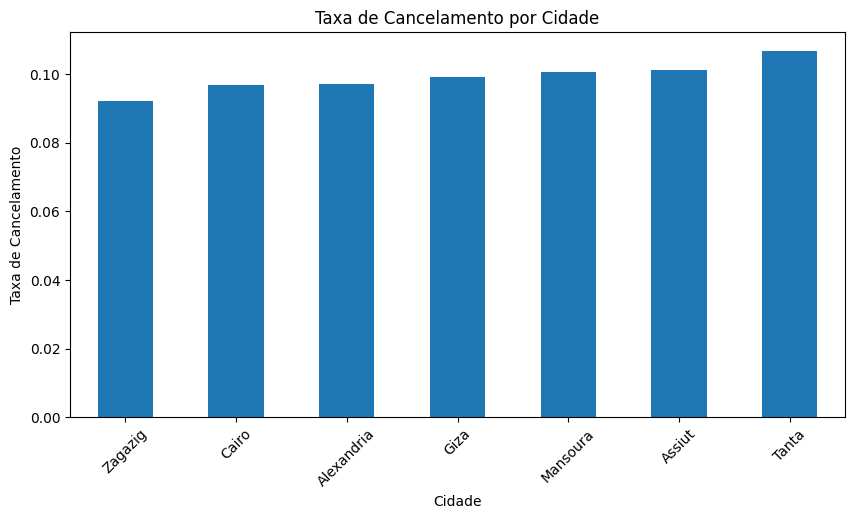

In [ ]:
city_data = df_model.merge(df[["City"]], left_index=True, right_index=True)

city_cancel_rate = city_data.groupby("City")["Target_Cancelled"].mean().sort_values()

plt.figure(figsize=(10,5))
city_cancel_rate.plot(kind="bar")

plt.title("Taxa de Cancelamento por Cidade")
plt.xlabel("Cidade")
plt.ylabel("Taxa de Cancelamento")
plt.xticks(rotation=45)

plt.show()

###Relação entre distância e tempo de entrega

Visualizar se entregas mais longas em distância geram maior tempo de entrega.

####Visualização da relação entre distância e tempo de entrega

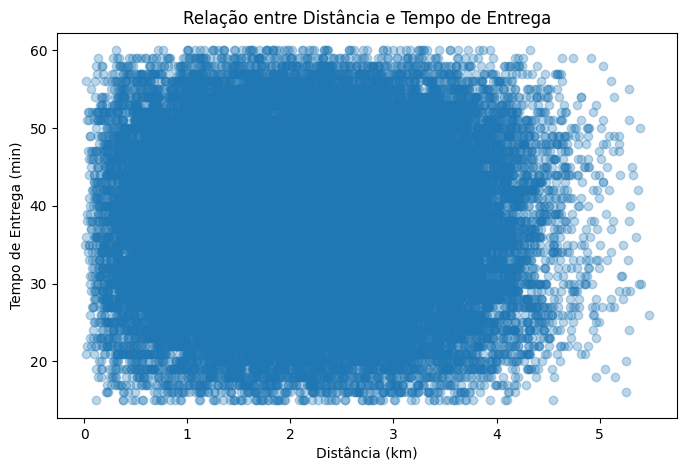

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Delivery_Distance_km"],
    df["Delivery_Duration_Minutes"],
    alpha=0.3
)

plt.title("Relação entre Distância e Tempo de Entrega")
plt.xlabel("Distância (km)")
plt.ylabel("Tempo de Entrega (min)")

plt.show()

#Conclusão final

O projeto teve como foco entender os fatores que influenciam o cancelamento de pedidos em uma plataforma de delivery, a partir da análise de mais de 100 mil registros. O objetivo principal foi investigar como variáveis operacionais, logísticas e comportamentais impactam a ocorrência de cancelamentos e, em paralelo, construir um modelo preditivo capaz de estimar esse evento.

##Principais resultados da análise exploratória

Ao longo da análise, foram avaliados diferentes fatores operacionais:

**Cidades:** apresentaram taxas de cancelamento muito semelhantes, indicando que o problema não está concentrado em regiões específicas.

**Tráfego:** não mostrou impacto relevante sobre cancelamentos ou tempo de entrega.

**Tipo de veículo:** também não apresentou diferenças significativas no comportamento de cancelamento ou eficiência.
Forma de pagamento: teve influência praticamente nula no cancelamento.

**Distância:** mostrou relação mais consistente com o tempo de entrega, mas não com cancelamentos.

De forma geral, os resultados indicam que o cancelamento é um fenômeno multifatorial, sem um único fator dominante explicando seu comportamento

##Resultados do modelo preditivo

Foram testadas duas abordagens principais:

**Modelo inicial**
* Alta acurácia (~90%)
* Porém, não identificava cancelamentos
* Fortemente enviesado para a classe majoritária

**Modelo adaptado**
* Acurácia reduzida (~51%)
* Melhor capacidade de identificar cancelamentos (~49% de recall)
* Maior equilíbrio entre as classes

O segundo modelo, mesmo com menor acurácia, mostrou-se mais adequado para o objetivo do projeto, pois passou a capturar o comportamento crítico (cancelamentos), que era ignorado anteriormente.

##Resposta ao problema de negócio

s cancelamentos não são explicados por um único fator isolado. As análises indicam que:

* Não há concentração relevante por cidade, veículo ou pagamento
* Variáveis individuais têm baixa correlação com cancelamento
* O comportamento é complexo e depende de múltiplos fatores combinados

Isso reforça a necessidade de abordagens multivariadas para compreensão e previsão do problema.

##Valor gerado pelo projeto

Este projeto entrega valor em três níveis principais:

* Análise exploratória: entendimento profundo da operação de delivery
* Modelagem preditiva: identificação de padrões associados a cancelamentos
* Insights operacionais: suporte para decisões estratégicas visando redução de cancelamentos

##Resultado geral

O estudo demonstrou que o cancelamento de pedidos em plataformas de delivery é um problema complexo e multifatorial, que não pode ser explicado por variáveis isoladas. Embora o modelo inicial tenha apresentado alta acurácia, ele não atendia ao objetivo principal do projeto.

Após o ajuste para lidar com desbalanceamento, foi possível construir um modelo mais útil do ponto de vista de negócio, capaz de identificar cancelamentos e apoiar decisões operacionais.

Assim, o projeto cumpre seu papel ao unir análise exploratória e modelagem preditiva para transformar dados em insights acionáveis, contribuindo para a melhoria da eficiência e da experiência do cliente em operações de delivery.

In [ ]:
df.to_csv("delivery_project.csv", index=False)